# Notebook 1: Dataset Discovery

**Course:** Data Engineering - Unsupervised Learning Project  
**University:** Bar-Ilan University, Spring 2026  
**Dataset:** NYC PLUTO - 858,644 lots/buildings across New York City  

## Sections Covered
- [x] **Section 1** - Basic Dataset Information
- [x] **Section 2** - Feature Understanding
- [x] **Section 3** - Missing Values

## Research Question
> *How can we build, from the physical, functional and geographical characteristics
> of the PLUTO dataset, an unsupervised segmentation of NYC buildings to identify
> homogeneous urban profiles and analyze their distribution across the five boroughs?*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os
%matplotlib inline

## Section 1: Basic Dataset Information

In [2]:
local_path = 'data/raw/pluto_working_copy.csv'
url = 'https://data.cityofnewyork.us/resource/64uk-42ks.csv?$limit=1000000'

if os.path.exists(local_path):
    print('Loading dataset from local working copy...')
    df = pd.read_csv(local_path, low_memory=False)
else:
    print('Local working copy not found. Downloading from NYC Open Data...')
    df = pd.read_csv(url, low_memory=False)
    os.makedirs('data/raw', exist_ok=True)
    df.to_csv(local_path, index=False)
    print('Working copy saved.')

os.makedirs('reports/figures', exist_ok=True)

# The raw CSV uses a Narrow No-Break Space (U+202F) as a thousands separator.
# pandas 3.x reads these columns as dtype 'str', so we use is_string_dtype().
numeric_cols = [
    'yearbuilt', 'lotarea', 'bldgarea', 'numfloors',
    'lotfront', 'lotdepth', 'unitstotal', 'unitsres',
    'resarea', 'comarea', 'officearea', 'retailarea',
    'garagearea', 'strgearea',
]
for col in numeric_cols:
    if col in df.columns and pd.api.types.is_string_dtype(df[col]):
        df[col] = df[col].astype(str).str.replace(r'[^\d.-]', '', regex=True)
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print('One row = one land lot or building in New York City.')
print('Domain: Urban data / Real estate / Land use')

Loading dataset from local working copy...


Dataset loaded: 858,644 rows, 101 columns
One row = one land lot or building in New York City.
Domain: Urban data / Real estate / Land use


In [3]:
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print('\nColumn data types:')
display(df.dtypes.value_counts().rename('count').to_frame())
print('\nFirst 5 rows:')
display(df.head())

Shape: 858,644 rows x 101 columns

Column data types:


,count
float64,53
str,40
int64,5
object,3



First 5 rows:


,borough,Tax block,Tax lot,community board,census tract 2010,cb2010,schooldist,council district,postcode,firecomp,...,bctcb2020,geom,basempdate,dcasdate,edesigdate,landmkdate,masdate,polidate,rpaddate,zoningdate
0,QN,6173,23,411.0,1123,1002.0,26.0,19.0,11361.0,E306,...,4.112300e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,QN,6173,24,411.0,1123,1002.0,26.0,19.0,11361.0,E306,...,4.112300e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,QN,6169,26,411.0,1123,2000.0,26.0,19.0,11361.0,E306,...,4.112300e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,QN,6172,1,411.0,1123,2001.0,26.0,19.0,11361.0,E306,...,4.112300e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,QN,6172,6,411.0,1123,2001.0,26.0,19.0,11361.0,E306,...,4.112300e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Section 2: Feature Understanding

In [4]:
selected_features = [
    # Physical features
    'lotarea', 'bldgarea', 'numfloors', 'lotfront', 'lotdepth', 'yearbuilt',
    # Functional features
    'landuse', 'unitstotal', 'unitsres', 'resarea', 'comarea',
    'officearea', 'retailarea', 'garagearea', 'strgearea',
    # Geographical features (for post-clustering interpretation only)
    'borough', 'zipcode', 'cd', 'latitude', 'longitude',
]
print(f'Total selected features: {len(selected_features)}')

Total selected features: 20


In [5]:
feature_understanding = pd.DataFrame({
    'Feature': [
        'lotarea', 'bldgarea', 'numfloors', 'lotfront', 'lotdepth', 'yearbuilt',
        'landuse', 'unitstotal', 'unitsres', 'resarea', 'comarea',
        'officearea', 'retailarea', 'garagearea', 'strgearea',
        'borough', 'zipcode', 'cd', 'latitude', 'longitude',
    ],
    'Group': [
        'Physical', 'Physical', 'Physical', 'Physical', 'Physical', 'Physical',
        'Functional', 'Functional', 'Functional', 'Functional', 'Functional',
        'Functional', 'Functional', 'Functional', 'Functional',
        'Geographical', 'Geographical', 'Geographical', 'Geographical', 'Geographical',
    ],
    'What it measures': [
        'Area of the land lot', 'Total building area', 'Number of floors',
        'Frontage of the lot', 'Depth of the lot', 'Year the building was built',
        'Main land use category', 'Total number of units', 'Number of residential units',
        'Residential area', 'Commercial area', 'Office area',
        'Retail area', 'Garage area', 'Storage area',
        'NYC borough', 'ZIP code area', 'Community district',
        'Geographical latitude', 'Geographical longitude',
    ],
    'Feature type': [
        'Numerical', 'Numerical', 'Numerical', 'Numerical', 'Numerical', 'Numerical / Temporal',
        'Categorical', 'Numerical', 'Numerical', 'Numerical', 'Numerical',
        'Numerical', 'Numerical', 'Numerical', 'Numerical',
        'Categorical', 'Categorical / Geographical', 'Categorical / Administrative',
        'Numerical / Geographical', 'Numerical / Geographical',
    ],
    'Possible values / units': [
        'Square feet', 'Square feet', 'Number of floors', 'Feet', 'Feet', 'Year',
        'Land use code/category', 'Number of units', 'Number of residential units',
        'Square feet', 'Square feet', 'Square feet', 'Square feet', 'Square feet', 'Square feet',
        'MN, BK, QN, BX, SI', 'ZIP code', 'Community district code',
        'Decimal degrees', 'Decimal degrees',
    ],
    'Scale concern': [
        'High', 'High', 'Low / Medium', 'Medium', 'Medium', 'Medium',
        'Not numeric before encoding', 'Medium / High', 'Medium / High',
        'High', 'High', 'High', 'High', 'High', 'High',
        'Not numeric before encoding', 'Not used as numeric scale',
        'Not used as numeric scale', 'Medium', 'Medium',
    ],
    'K-Means role': [
        'Input', 'Input', 'Input', 'Input', 'Input', 'Input',
        'Input (encoded)', 'Input', 'Input', 'Input', 'Input',
        'Input', 'Input', 'Input', 'Input',
        'Interpretation only', 'Interpretation only', 'Interpretation only',
        'Interpretation only', 'Interpretation only',
    ],
})

display(feature_understanding.style
        .set_caption('Feature Understanding Table - 20 Selected Features')
        .set_properties(**{'text-align': 'left'})
        .hide(axis='index'))

Feature,Group,What it measures,Feature type,Possible values / units,Scale concern,K-Means role
lotarea,Physical,Area of the land lot,Numerical,Square feet,High,Input
bldgarea,Physical,Total building area,Numerical,Square feet,High,Input
numfloors,Physical,Number of floors,Numerical,Number of floors,Low / Medium,Input
lotfront,Physical,Frontage of the lot,Numerical,Feet,Medium,Input
lotdepth,Physical,Depth of the lot,Numerical,Feet,Medium,Input
yearbuilt,Physical,Year the building was built,Numerical / Temporal,Year,Medium,Input
landuse,Functional,Main land use category,Categorical,Land use code/category,Not numeric before encoding,Input (encoded)
unitstotal,Functional,Total number of units,Numerical,Number of units,Medium / High,Input
unitsres,Functional,Number of residential units,Numerical,Number of residential units,Medium / High,Input
resarea,Functional,Residential area,Numerical,Square feet,High,Input


## Section 3: Missing Values

In [6]:
selected_features_available = [f for f in selected_features if f in df.columns]
selected_features_missing = [f for f in selected_features if f not in df.columns]

print(f'Selected features found in dataset : {len(selected_features_available)}')
if selected_features_missing:
    print(f'Selected features NOT found        : {selected_features_missing}')
else:
    print('All 20 selected features are present in this dataset export.')

Selected features found in dataset : 18
Selected features NOT found        : ['zipcode', 'cd']


In [7]:
missing_values = df[selected_features_available].isna().sum()
missing_pct = (missing_values / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Feature': selected_features_available,
    'Missing values': missing_values.values,
    'Missing %': missing_pct.values,
}).sort_values('Missing %', ascending=False).reset_index(drop=True)

print('Missing values summary - 20 selected features:')
display(missing_summary.style.background_gradient(subset=['Missing %'], cmap='Reds'))

Missing values summary - 20 selected features:


,Feature,Missing values,Missing %
0,resarea,46449,5.410000
1,comarea,46449,5.410000
2,strgearea,46449,5.410000
3,garagearea,46449,5.410000
4,retailarea,46449,5.410000
5,officearea,46449,5.410000
6,numfloors,42363,4.930000
7,landuse,2713,0.320000
8,latitude,1483,0.170000
9,longitude,1483,0.170000


In [8]:
empty_strings = (df[selected_features_available] == '').sum()
empty_df = pd.DataFrame({
    'Feature': selected_features_available,
    'Empty string count': empty_strings.values,
}).query('`Empty string count` > 0')

if empty_df.empty:
    print('No empty strings found in any of the 20 selected features.')
else:
    print('Features with empty strings:')
    display(empty_df)

No empty strings found in any of the 20 selected features.


In [9]:
special_codes = [-999, '-999', 'NULL', 'null', 'NA', 'N/A']

rows = []
for feature in selected_features_available:
    counts = {str(code): int((df[feature] == code).sum()) for code in special_codes}
    counts['Feature'] = feature
    rows.append(counts)

special_df = pd.DataFrame(rows).set_index('Feature')
non_zero = special_df[(special_df > 0).any(axis=1)]

if non_zero.empty:
    print('No special missing-value codes (-999, NULL, NA, N/A) found in the 20 selected features.')
else:
    print('Features with special missing-value codes:')
    display(non_zero)

No special missing-value codes (-999, NULL, NA, N/A) found in the 20 selected features.


In [10]:
nearly_empty_selected = missing_summary[missing_summary['Missing %'] > 50]
if nearly_empty_selected.empty:
    print('No selected feature exceeds 50% missing values.')
else:
    print('Selected features with >50% missing values:')
    display(nearly_empty_selected)

No selected feature exceeds 50% missing values.


In [11]:
all_missing = df.isna().sum()
all_pct = (all_missing / len(df) * 100).round(2)

all_missing_df = pd.DataFrame({
    'Feature': df.columns,
    'Missing values': all_missing.values,
    'Missing %': all_pct.values,
})

nearly_empty_all = (
    all_missing_df[all_missing_df['Missing %'] > 50]
    .sort_values('Missing %', ascending=False)
    .reset_index(drop=True)
)

print(f'Full dataset: {len(nearly_empty_all)} columns with >50% missing values '
      f'(out of {df.shape[1]} total columns).')
display(nearly_empty_all)

Full dataset: 30 columns with >50% missing values (out of 101 total columns).


,Feature,Missing values,Missing %
0,zoningdate,858644,100.00
1,spdist3,858644,100.00
2,basempdate,858644,100.00
3,dcasdate,858644,100.00
4,edesigdate,858644,100.00
5,notes,858644,100.00
6,masdate,858644,100.00
7,landmkdate,858644,100.00
8,polidate,858644,100.00
9,rpaddate,858644,100.00


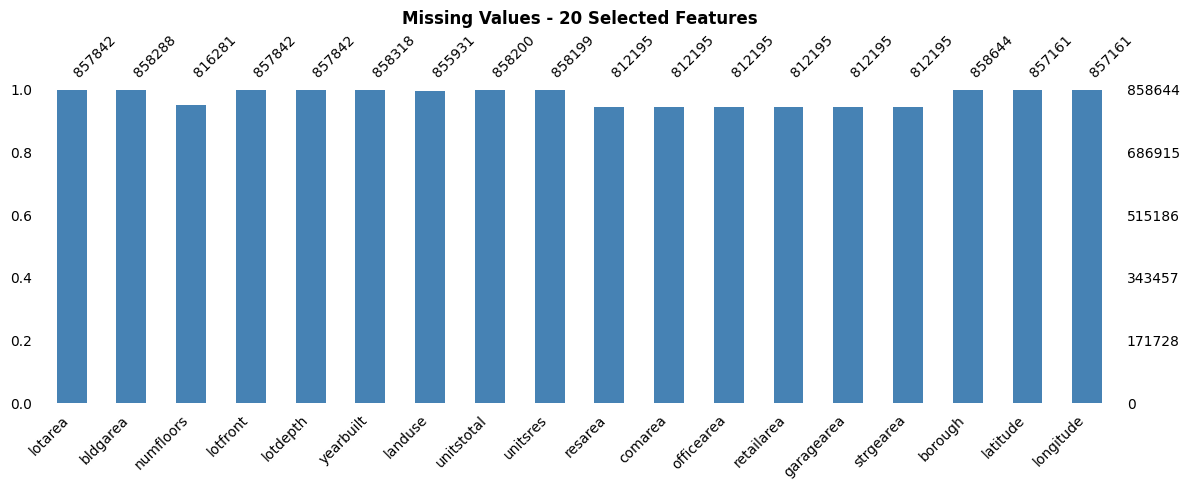

Saved: reports/figures/01_missingno_bar.png


In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
msno.bar(df[selected_features_available], ax=ax, color='steelblue', fontsize=10)
ax.set_title('Missing Values - 20 Selected Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/01_missingno_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/figures/01_missingno_bar.png')

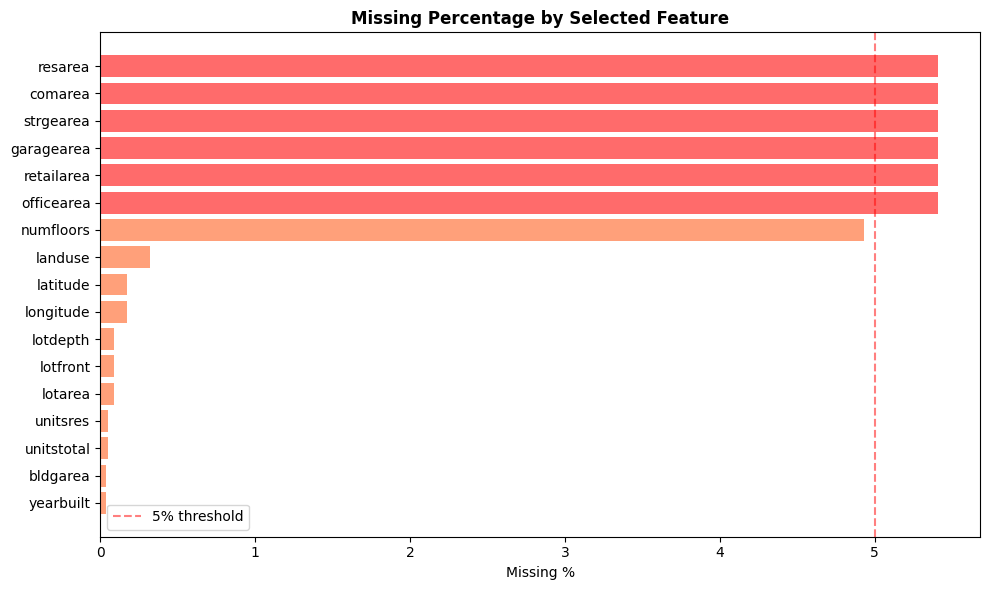

Saved: reports/figures/01_missing_pct.png


In [13]:
missing_plot = missing_summary[missing_summary['Missing %'] > 0].sort_values('Missing %')

if missing_plot.empty:
    print('All selected features have 0% missing values.')
else:
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#FF6B6B' if v > 5 else '#FFA07A' for v in missing_plot['Missing %']]
    ax.barh(missing_plot['Feature'], missing_plot['Missing %'], color=colors)
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Percentage by Selected Feature', fontsize=12, fontweight='bold')
    ax.axvline(x=5, color='red', linestyle='--', alpha=0.5, label='5% threshold')
    ax.legend()
    plt.tight_layout()
    plt.savefig('reports/figures/01_missing_pct.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: reports/figures/01_missing_pct.png')

## Key Findings from Notebook 1

1. **Dataset confirmed:** 858,644 rows and 101 columns. One row represents one land lot or building in NYC.
2. **Feature selection:** 20 features selected from 101 available, grouped into Physical (6), Functional (9), and Geographical (5). The remaining 81 columns were excluded due to irrelevance or high missingness.
3. **Missing values in selected features:** Mostly under 5% for the 20 selected features. The area sub-features (comarea, officearea, retailarea, garagearea, strgearea) have ~5.4% missing, which is acceptable.
4. **Special encoded missing values:** No occurrences of -999, NULL, NA, or N/A were found in any of the 20 selected features.
5. **Full dataset missing values:** Several columns in the full 101-column dataset have >50% missing values, which is the primary reason feature selection was restricted to the 20 chosen features.